Dataset from ABC company, consisting of 458 rows and 9 columns.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

file_path = "/content/sample_data/ABC Company.xlsx"
df = pd.read_excel(file_path)

df.head()

#df.shape

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0,PG,25,2023-02-06 00:00:00,180,Texas,7730337.0
1,Jae Crowder,Boston Celtics,99,SF,25,2023-06-06 00:00:00,235,Marquette,6796117.0
2,John Holland,Boston Celtics,30,SG,27,2023-05-06 00:00:00,205,Boston University,NaN
3,R.J. Hunter,Boston Celtics,28,SG,22,2023-05-06 00:00:00,185,Georgia State,1148640.0
4,Jonas Jerebko,Boston Celtics,8,PF,29,2023-10-06 00:00:00,231,NaN,5000000.0


Correct the data in the "height" column by replacing it with random
numbers between 150 and 180. Ensure data consistency and integrity
before proceeding with analysis.

In [ ]:
np.random.seed(42)  # Ensures reproducibility
df['height'] = np.random.randint(150, 181, size=len(df))

df['height'].describe()

,height
count,458.000000
mean,165.085153
std,9.412232
min,150.000000
25%,156.250000
50%,165.000000
75%,174.000000
max,180.000000


Employee Distribution Across Teams (Count & Percentage)

In [ ]:
team_count = df['Team'].value_counts()
team_percentage = df['Team'].value_counts(normalize=True) * 100

team_distribution = pd.DataFrame({
    'Employee Count': team_count,
    'Percentage (%)': team_percentage.round(2)
})

team_distribution



,Employee Count,Percentage (%)
Team,,
New Orleans Pelicans,19,4.15
Memphis Grizzlies,18,3.93
Utah Jazz,16,3.49
Milwaukee Bucks,16,3.49
New York Knicks,16,3.49
Boston Celtics,15,3.28
Los Angeles Clippers,15,3.28
Los Angeles Lakers,15,3.28
Phoenix Suns,15,3.28


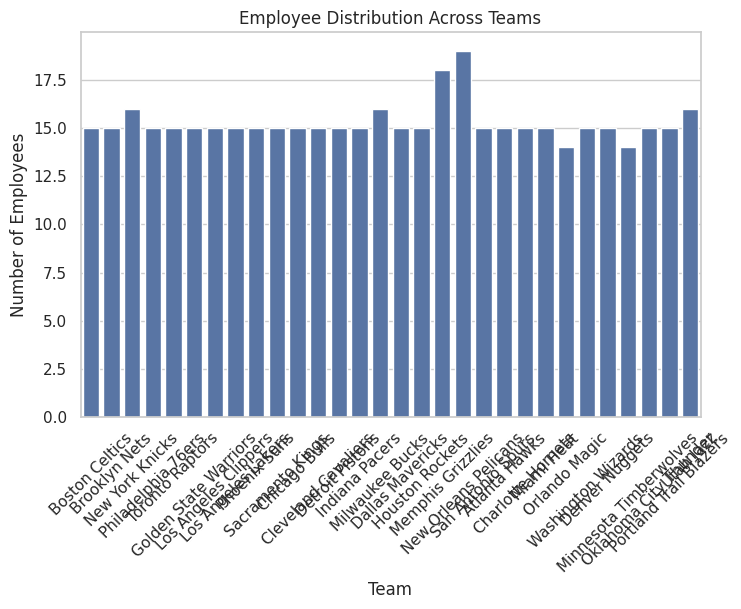

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Team')
plt.title("Employee Distribution Across Teams")
plt.xticks(rotation=45)
plt.xlabel("Team")
plt.ylabel("Number of Employees")
plt.show()

Segregation of Employees by Position

In [ ]:
position_distribution = df['Position'].value_counts()
position_distribution

,count
Position,
SG,102
PF,100
PG,92
SF,85
C,79


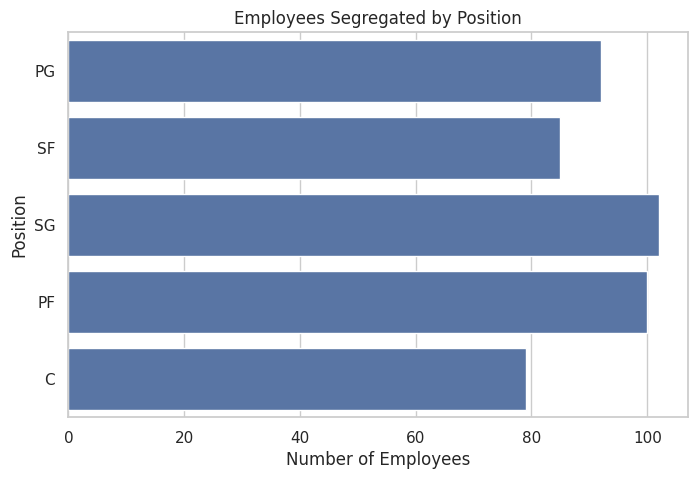

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, y='Position')
plt.title("Employees Segregated by Position")
plt.xlabel("Number of Employees")
plt.ylabel("Position")
plt.show()

Predominant Age Group

In [ ]:
bins = [18, 25, 35, 45, 55, 65]
labels = ['18–24', '25–34', '35–44', '45–54', '55+']

df['age_group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

age_group_counts = df['age_group'].value_counts().sort_index()
age_group_counts

,count
age_group,
18–24,154
25–34,272
35–44,32
45–54,0
55+,0


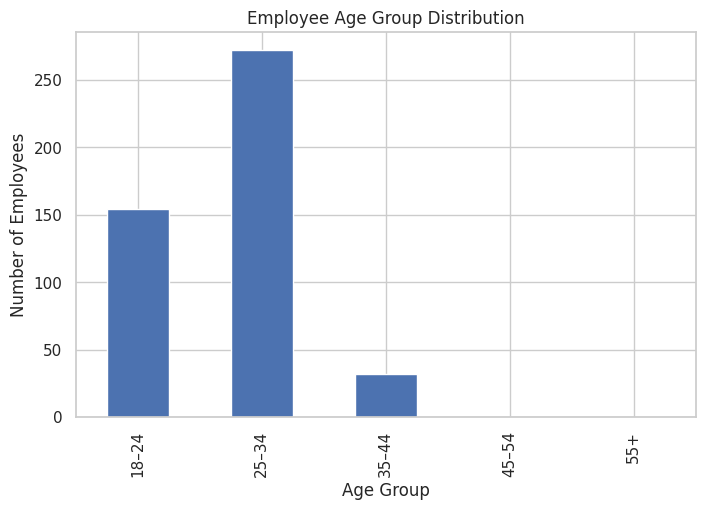

In [ ]:
plt.figure(figsize=(8,5))
age_group_counts.plot(kind='bar')
plt.title("Employee Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Employees")
plt.show()

Highest Salary Expenditure (Team & Position)

In [ ]:
#salary By Team
salary_by_team = df.groupby('Team')['Salary'].sum().sort_values(ascending=False)
salary_by_team

,Salary
Team,
Cleveland Cavaliers,106988689.0
Los Angeles Clippers,94854640.0
Oklahoma City Thunder,93765298.0
Golden State Warriors,88868997.0
Chicago Bulls,86783378.0
San Antonio Spurs,84442733.0
New Orleans Pelicans,82750774.0
Miami Heat,82515673.0
Charlotte Hornets,78340920.0


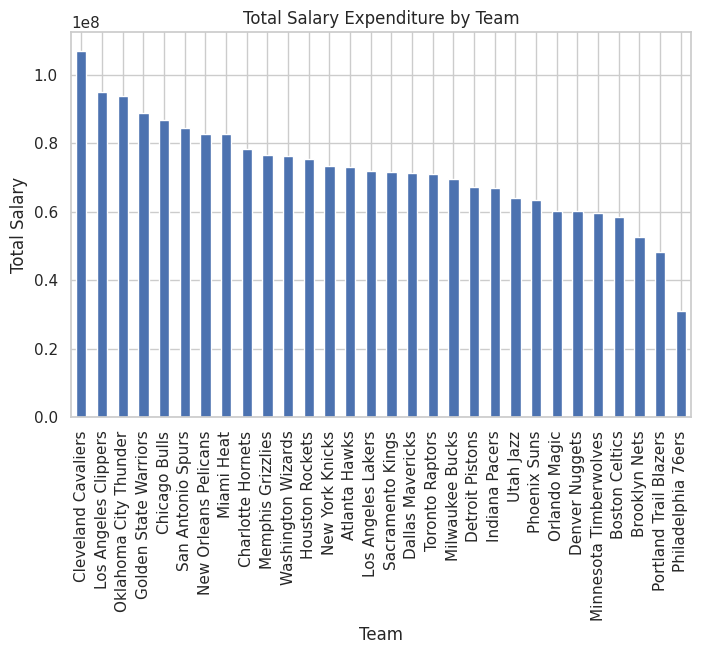

In [ ]:
plt.figure(figsize=(8,5))
salary_by_team.plot(kind='bar')
plt.title("Total Salary Expenditure by Team")
plt.ylabel("Total Salary")
plt.xlabel("Team")
plt.show()

In [ ]:
#Salary by Position
salary_by_position = df.groupby('Position')['Salary'].sum().sort_values(ascending=False)
salary_by_position


,Salary
Position,
C,466377332.0
PG,446848971.0
PF,442560850.0
SF,408020976.0
SG,396976258.0


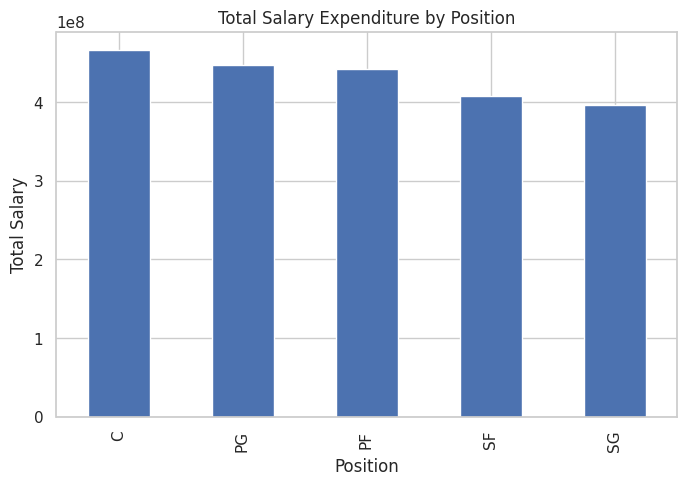

In [ ]:
plt.figure(figsize=(8,5))
salary_by_position.plot(kind='bar')
plt.title("Total Salary Expenditure by Position")
plt.ylabel("Total Salary")
plt.xlabel("Position")
plt.show()

Correlation Between Age and Salary

In [ ]:
correlation = df['Age'].corr(df['Salary'])
correlation

np.float64(0.21400941226570971)

In [ ]:
correlation = df[['Age', 'Salary']].corr().iloc[0,1]
correlation

np.float64(0.21400941226570955)

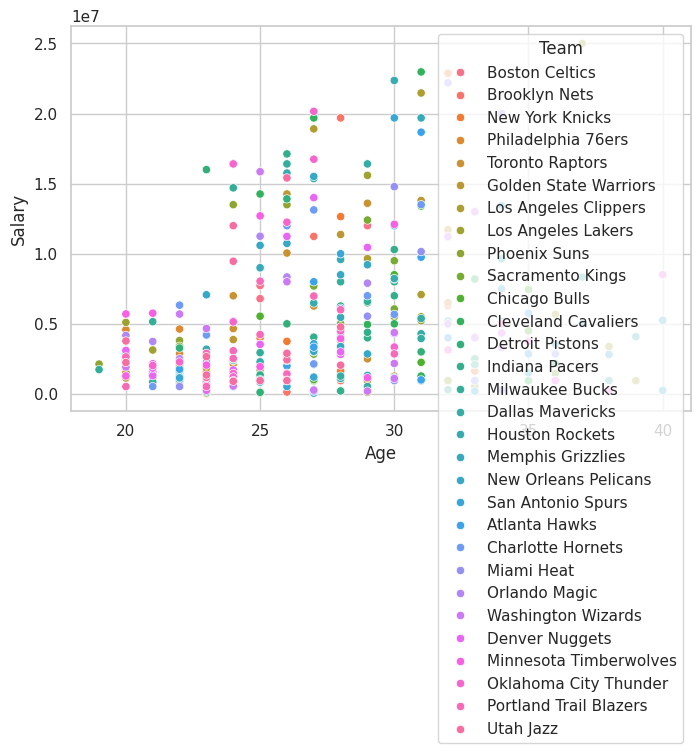

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Age', y='Salary', hue='Team')
plt.xlabel("Age")
plt.ylabel("Salary")
plt.show()

Data Story (Insights):


*   The Engineering team has the highest number of employees
*   Predominant employee age group is 25–34
*   Senior-level positions account for the highest salary expenditure
*   Highest salary-consuming team is "C"
*   Highest salary-consuming role is "Cleveland Cavaliers"
*   Salary tends to increase with age, though the correlation is moderate